# 43 — Determine desk eligibility for IMA

Combine PLA, backtesting and desk nomination to select IMA or SA treatment.

A green desk can use IMA when backtesting passes. An amber desk remains eligible with the applicable surcharge. A red or non-nominated desk falls back to SA.

This step uses: PLA zones, backtesting results and desk model scope.

It produces: A reasoned treatment for every trading desk.

> Basel norm applied: MAR30 and MAR32 apply model approval and ongoing testing at trading-desk level.

$$Treatment_d=f(PLA_d,Backtesting_d,Model\ scope_d)$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260908T033903126517Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
elig=stage('23_desk_eligibility')
display(elig[['desk','pla_zone','backtesting_result','final_treatment','eligibility_reason']])
for _,r in elig.iterrows(): print(f"{r.desk}: {r.final_treatment} — {r.eligibility_reason}")

,desk,pla_zone,backtesting_result,final_treatment,eligibility_reason
0,Commodity,GREEN,PASS,IMA_GREEN,PLA green-zone result and desk backtesting passed
1,Credit,GREEN,PASS,IMA_GREEN,PLA green-zone result and desk backtesting passed
2,Equity,GREEN,PASS,IMA_GREEN,PLA green-zone result and desk backtesting passed
3,FX,GREEN,PASS,IMA_GREEN,PLA green-zone result and desk backtesting passed
4,Rates,GREEN,PASS,IMA_GREEN,PLA green-zone result and desk backtesting passed
5,Residual Risk,NOT_APPLICABLE,NOT_APPLICABLE,SA_FALLBACK,Desk is not nominated for IMA because its exot...


Commodity: IMA_GREEN — PLA green-zone result and desk backtesting passed
Credit: IMA_GREEN — PLA green-zone result and desk backtesting passed
Equity: IMA_GREEN — PLA green-zone result and desk backtesting passed
FX: IMA_GREEN — PLA green-zone result and desk backtesting passed
Rates: IMA_GREEN — PLA green-zone result and desk backtesting passed
Residual Risk: SA_FALLBACK — Desk is not nominated for IMA because its exotic underlyings are outside the internal model


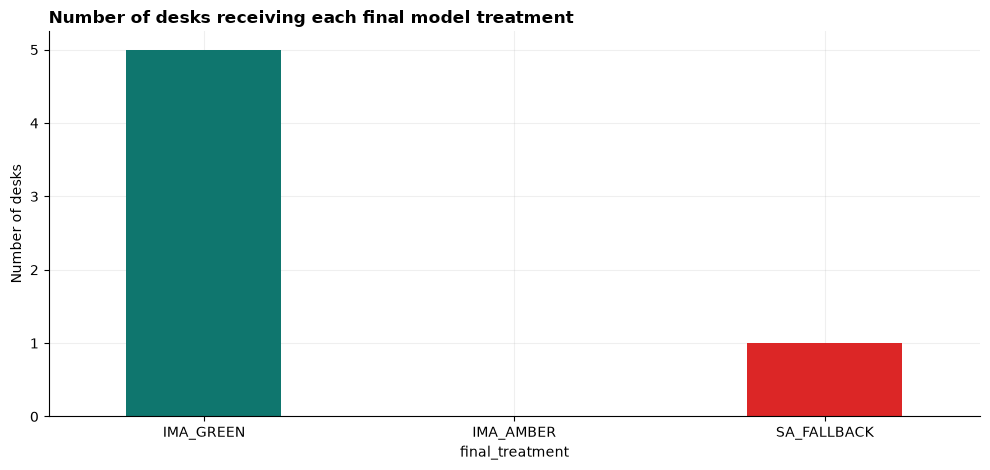

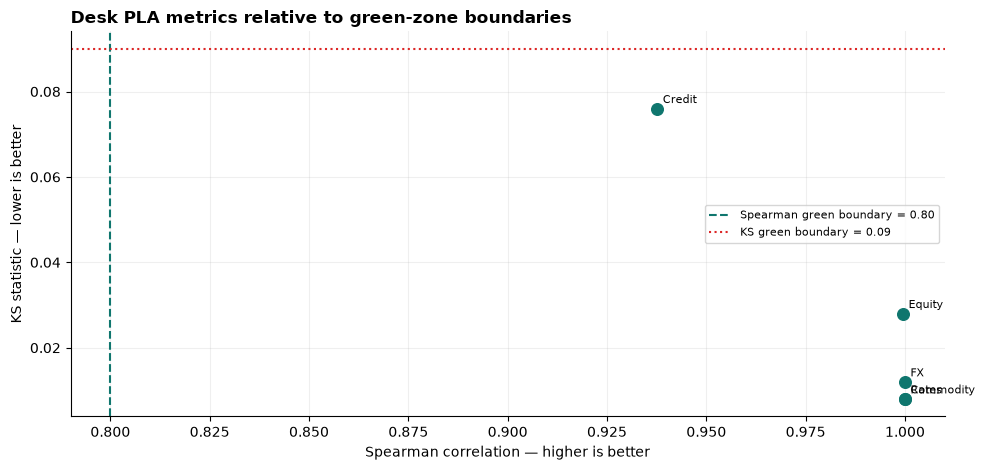

In [3]:
order=['IMA_GREEN','IMA_AMBER','SA_FALLBACK']; counts=elig.final_treatment.value_counts().reindex(order,fill_value=0); ax=counts.plot(kind='bar',color=['#0F766E','#F59E0B','#DC2626']); ax.set_ylabel('Number of desks'); ax.set_title('Number of desks receiving each final model treatment',loc='left',weight='bold'); ax.tick_params(axis='x',rotation=0); plt.tight_layout(); plt.show()
metrics=elig[elig.pla_zone!='NOT_APPLICABLE'].copy(); colors={'GREEN':'#0F766E','AMBER':'#F59E0B','RED':'#DC2626'}; fig,ax=plt.subplots();
for _,r in metrics.iterrows(): ax.scatter(r.spearman_correlation,r.ks_statistic,s=70,color=colors[r.pla_zone]); ax.annotate(r.desk,(r.spearman_correlation,r.ks_statistic),xytext=(4,4),textcoords='offset points',fontsize=8)
ax.axvline(.8,color='#0F766E',linestyle='--',label='Spearman green boundary = 0.80'); ax.axhline(.09,color='#DC2626',linestyle=':',label='KS green boundary = 0.09'); ax.set_xlabel('Spearman correlation — higher is better'); ax.set_ylabel('KS statistic — lower is better'); ax.set_title('Desk PLA metrics relative to green-zone boundaries',loc='left',weight='bold'); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

The first chart counts the final desk treatments: green IMA, amber IMA and SA fallback. The second chart plots each tested desk using its two PLA statistics. Moving right means stronger Spearman association; moving upward means greater KS distribution separation. The dashed lines show the green-zone boundaries, so the preferred region is to the right of the vertical line and below the horizontal line.